# Phase 3 — Analytics

**Goal:** Compute the following per zone:
- Live occupancy count
- Total unique visitors (a person re-entering the same zone should not be double counted)
- Average dwell time in seconds
- Peak occupancy and the timestamp it occurred


In [1]:
import json
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import defaultdict
from pathlib import Path

TRACKS_ZONED_PATH = Path('../outputs/analytics/tracks_with_zones.json')
ZONES_JSON_PATH   = Path('../outputs/analytics/zones.json')
ANALYTICS_JSON    = Path('../outputs/analytics/zone_analytics.json')
ANALYTICS_CSV     = Path('../outputs/analytics/zone_analytics.csv')
FRAME_LOG_CSV     = Path('../outputs/analytics/frame_occupancy_log.csv')

assert TRACKS_ZONED_PATH.exists(), f'Run Phase 2 first — missing: {TRACKS_ZONED_PATH}'

with open(TRACKS_ZONED_PATH) as f:
    data = json.load(f)

with open(ZONES_JSON_PATH) as f:
    zones_config = json.load(f)

FPS    = data['metadata']['fps']
tracks = data['tracks']
zones  = {z['id']: z for z in zones_config}

MIN_DWELL_SECONDS = 0.5

print(f'✅ Loaded {len(tracks)} tracks, {len(zones)} zones @ {FPS:.2f}fps')

✅ Loaded 66 tracks, 4 zones @ 25.00fps


In [2]:
def extract_visit_epochs(track_records: list, min_dwell: float = 0.5) -> dict:
    epochs = defaultdict(list)
    
    if not track_records:
        return epochs
    
    current_zone = None
    epoch_start  = None
    
    for rec in track_records:
        zid = rec['zone_id']
        ts  = rec['timestamp']
        
        if zid != current_zone:
            if current_zone is not None and epoch_start is not None:
                duration = ts - epoch_start
                if duration >= min_dwell:
                    epochs[current_zone].append({
                        'enter': round(epoch_start, 3),
                        'exit' : round(ts, 3),
                        'dwell': round(duration, 3)
                    })
            
            current_zone = zid
            epoch_start  = ts if zid is not None else None
    
    if current_zone is not None and epoch_start is not None:
        last_ts  = track_records[-1]['timestamp']
        duration = last_ts - epoch_start
        if duration >= min_dwell:
            epochs[current_zone].append({
                'enter': round(epoch_start, 3),
                'exit' : round(last_ts, 3),
                'dwell': round(duration, 3)
            })
    
    return dict(epochs)


all_epochs = {}
for tid, records in tracks.items():
    all_epochs[tid] = extract_visit_epochs(records, MIN_DWELL_SECONDS)

print(f'✅ Visit epochs extracted for {len(all_epochs)} tracks.')
sample_tid = list(all_epochs.keys())[0]
print(f'   Sample track {sample_tid}: {all_epochs[sample_tid]}')

✅ Visit epochs extracted for 66 tracks.
   Sample track 1: {3: [{'enter': 0.08, 'exit': 5.44, 'dwell': 5.36}], 1: [{'enter': 5.44, 'exit': 13.6, 'dwell': 8.16}]}


In [3]:
zone_stats = {}

for zone_id, zone_info in zones.items():
    unique_visitors = set()
    all_dwell_times = []
    total_entries   = 0
    
    for tid, epoch_map in all_epochs.items():
        if zone_id in epoch_map:
            unique_visitors.add(tid)
            for ep in epoch_map[zone_id]:
                all_dwell_times.append(ep['dwell'])
                total_entries += 1
    
    avg_dwell = np.mean(all_dwell_times)  if all_dwell_times else 0.0
    max_dwell = np.max(all_dwell_times)   if all_dwell_times else 0.0
    total_dwell = np.sum(all_dwell_times) if all_dwell_times else 0.0
    
    zone_stats[zone_id] = {
        'zone_id'        : zone_id,
        'zone_name'      : zone_info['name'],
        'unique_visitors': len(unique_visitors),
        'total_entries'  : total_entries,
        'avg_dwell_sec'  : round(avg_dwell, 2),
        'max_dwell_sec'  : round(max_dwell, 2),
        'total_dwell_sec': round(total_dwell, 2),
        'peak_occupancy' : None,
        'peak_timestamp' : None,
        'peak_frame'     : None,
    }

print('=== Per-Zone Aggregation ===')
for zid, stats in zone_stats.items():
    print(f"  Zone {zid} ({stats['zone_name']})")
    print(f"    Unique visitors : {stats['unique_visitors']}")
    print(f"    Total entries   : {stats['total_entries']}")
    print(f"    Avg dwell       : {stats['avg_dwell_sec']}s")
    print(f"    Max dwell       : {stats['max_dwell_sec']}s")
    print()

=== Per-Zone Aggregation ===
  Zone 0 (Entrance)
    Unique visitors : 19
    Total entries   : 22
    Avg dwell       : 5.0s
    Max dwell       : 13.52s

  Zone 1 (Checkout Area)
    Unique visitors : 27
    Total entries   : 27
    Avg dwell       : 4.93s
    Max dwell       : 12.44s

  Zone 2 (Aisle)
    Unique visitors : 18
    Total entries   : 22
    Avg dwell       : 4.27s
    Max dwell       : 13.52s

  Zone 3 (Exit)
    Unique visitors : 21
    Total entries   : 26
    Avg dwell       : 2.79s
    Max dwell       : 5.6s



In [4]:
from tqdm.notebook import tqdm
all_frame_indices = set()
for tid, records in tracks.items():
    for rec in records:
        all_frame_indices.add(rec['frame'])

all_frame_indices = sorted(all_frame_indices)
MAX_FRAME = max(all_frame_indices)

frame_zone_map = defaultdict(lambda: defaultdict(set))

for tid, records in tqdm(tracks.items(), desc='Building frame map'):
    for rec in records:
        fi  = rec['frame']
        zid = rec['zone_id']
        if zid is not None:
            frame_zone_map[fi][zid].add(tid)

frame_log_rows = []
zone_ids_list  = sorted(zones.keys())

for fi in all_frame_indices:
    ts   = round(fi / FPS, 3)
    row  = {'frame': fi, 'timestamp': ts}
    for zid in zone_ids_list:
        count = len(frame_zone_map[fi][zid])
        row[f'zone_{zid}_occupancy'] = count
        row[f'zone_{zid}_name']      = zones[zid]['name']
    frame_log_rows.append(row)

print(f'✅ Frame log built: {len(frame_log_rows)} frames')

for zid in zone_ids_list:
    col   = f'zone_{zid}_occupancy'
    max_v = 0
    max_f = 0
    max_t = 0.0
    for row in frame_log_rows:
        if row[col] > max_v:
            max_v = row[col]
            max_f = row['frame']
            max_t = row['timestamp']
    zone_stats[zid]['peak_occupancy'] = max_v
    zone_stats[zid]['peak_frame']     = max_f
    zone_stats[zid]['peak_timestamp'] = max_t

print('Peak occupancy per zone:')
for zid, stats in zone_stats.items():
    print(f"  {stats['zone_name']}: peak={stats['peak_occupancy']} at t={stats['peak_timestamp']}s (frame {stats['peak_frame']})")

Building frame map:   0%|          | 0/66 [00:00<?, ?it/s]

✅ Frame log built: 339 frames
Peak occupancy per zone:
  Entrance: peak=11 at t=0.72s (frame 18)
  Checkout Area: peak=14 at t=12.44s (frame 311)
  Aisle: peak=9 at t=4.56s (frame 114)
  Exit: peak=8 at t=11.68s (frame 292)


In [5]:
final_analytics = {
    'metadata': data['metadata'],
    'config': {
        'min_dwell_threshold_sec': MIN_DWELL_SECONDS,
        'boundary_rule': 'priority_order_first_match',
        'ground_point': 'bottom_center_bbox'
    },
    'zone_summary': list(zone_stats.values()),
    'visit_epochs': {
        tid: {str(k): v for k, v in epoch_map.items()}
        for tid, epoch_map in all_epochs.items()
    }
}

with open(ANALYTICS_JSON, 'w') as f:
    json.dump(final_analytics, f, indent=2)
print(f'✅ Analytics JSON: {ANALYTICS_JSON}')

csv_rows = list(zone_stats.values())
with open(ANALYTICS_CSV, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=csv_rows[0].keys())
    writer.writeheader()
    writer.writerows(csv_rows)
print(f'✅ Analytics CSV:  {ANALYTICS_CSV}')

log_fields = ['frame', 'timestamp'] + \
             [f'zone_{z}_occupancy' for z in zone_ids_list]

with open(FRAME_LOG_CSV, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=log_fields, extrasaction='ignore')
    writer.writeheader()
    writer.writerows(frame_log_rows)
print(f'✅ Frame log CSV:  {FRAME_LOG_CSV}')

✅ Analytics JSON: ..\outputs\analytics\zone_analytics.json
✅ Analytics CSV:  ..\outputs\analytics\zone_analytics.csv
✅ Frame log CSV:  ..\outputs\analytics\frame_occupancy_log.csv


C:\Users\reach\AppData\Local\Temp\ipykernel_3180\1007035652.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(dwell_by_zone, labels=zone_names, patch_artist=True, notch=False)


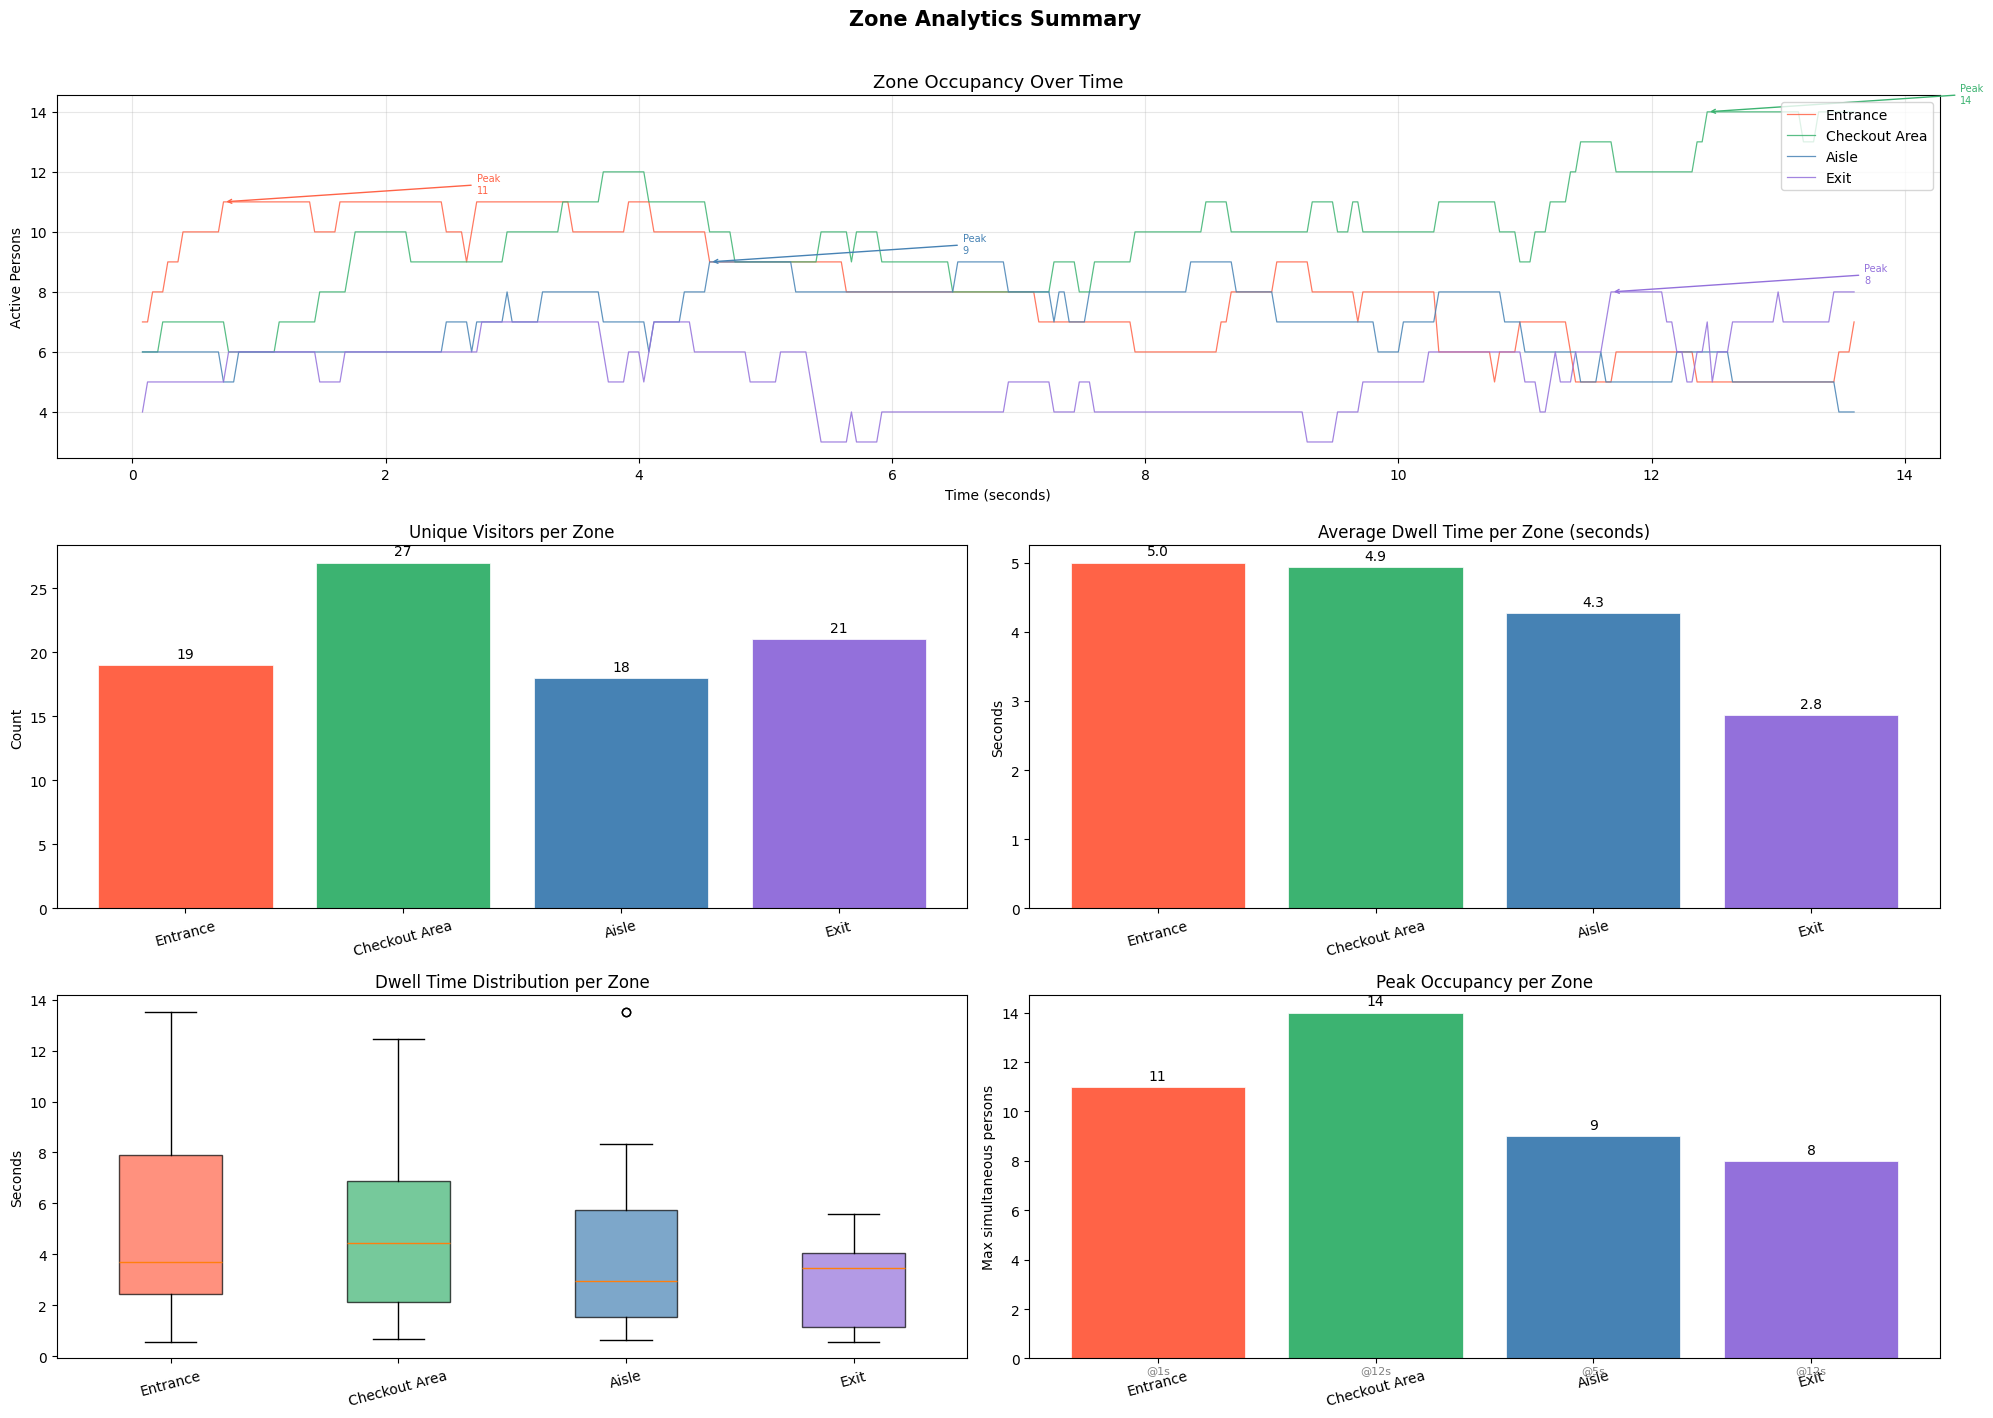

✅ Analytics chart saved: outputs/analytics/analytics_summary.png


In [6]:
df = pd.DataFrame(frame_log_rows)
occ_cols = [f'zone_{z}_occupancy' for z in zone_ids_list]
zone_names = [zones[z]['name'] for z in zone_ids_list]

fig = plt.figure(figsize=(20, 14))

ax1 = fig.add_subplot(3, 2, (1, 2))
colors_plot = ['#FF6347', '#3CB371', '#4682B4', '#9370DB']

for col, name, color in zip(occ_cols, zone_names, colors_plot):
    ax1.plot(df['timestamp'], df[col], label=name, color=color,
             linewidth=0.9, alpha=0.85)

ax1.set_title('Zone Occupancy Over Time', fontsize=13)
ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Active Persons')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

for zid, stats, color in zip(zone_ids_list, zone_stats.values(), colors_plot):
    t = stats['peak_timestamp']
    v = stats['peak_occupancy']
    ax1.annotate(f'Peak\n{v}', xy=(t, v), xytext=(t+2, v+0.3),
                 fontsize=7, color=color,
                 arrowprops=dict(arrowstyle='->', color=color, lw=1))

ax2 = fig.add_subplot(3, 2, 3)
uv   = [zone_stats[z]['unique_visitors'] for z in zone_ids_list]
bars = ax2.bar(zone_names, uv, color=colors_plot, edgecolor='white', linewidth=0.5)
ax2.bar_label(bars, padding=3)
ax2.set_title('Unique Visitors per Zone')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=15)
ax3 = fig.add_subplot(3, 2, 4)
ad   = [zone_stats[z]['avg_dwell_sec'] for z in zone_ids_list]
bars = ax3.bar(zone_names, ad, color=colors_plot, edgecolor='white', linewidth=0.5)
ax3.bar_label(bars, fmt='%.1f', padding=3)
ax3.set_title('Average Dwell Time per Zone (seconds)')
ax3.set_ylabel('Seconds')
ax3.tick_params(axis='x', rotation=15)
ax4 = fig.add_subplot(3, 2, 5)
dwell_by_zone = []
for zid in zone_ids_list:
    dwells = []
    for tid, epoch_map in all_epochs.items():
        if zid in epoch_map:
            dwells.extend([ep['dwell'] for ep in epoch_map[zid]])
    dwell_by_zone.append(dwells if dwells else [0])

bp = ax4.boxplot(dwell_by_zone, labels=zone_names, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], colors_plot):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax4.set_title('Dwell Time Distribution per Zone')
ax4.set_ylabel('Seconds')
ax4.tick_params(axis='x', rotation=15)
ax5 = fig.add_subplot(3, 2, 6)
po   = [zone_stats[z]['peak_occupancy'] for z in zone_ids_list]
pt   = [zone_stats[z]['peak_timestamp'] for z in zone_ids_list]
bars = ax5.bar(zone_names, po, color=colors_plot, edgecolor='white', linewidth=0.5)
ax5.bar_label(bars, padding=3)
ax5.set_title('Peak Occupancy per Zone')
ax5.set_ylabel('Max simultaneous persons')
ax5.tick_params(axis='x', rotation=15)
for i, (bar, t) in enumerate(zip(bars, pt)):
    ax5.text(bar.get_x() + bar.get_width()/2, -0.6,
             f'@{t:.0f}s', ha='center', fontsize=8, color='gray')

plt.suptitle('Zone Analytics Summary', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/analytics/analytics_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Analytics chart saved: outputs/analytics/analytics_summary.png')

In [7]:
print('='*65)
print(f'  FINAL ZONE ANALYTICS SUMMARY')
print('='*65)
print(f'{"Zone":<20} {"Unique":>8} {"Entries":>8} {"AvgDwell":>10} {"MaxDwell":>10} {"Peak":>6} {"PeakAt":>8}')
print(f'{"":<20} {"Visitors":>8} {"":>8} {"(sec)":>10} {"(sec)":>10} {"Occ":>6} {"(sec)":>8}')
print('-'*65)
for zid in zone_ids_list:
    s = zone_stats[zid]
    print(f"{s['zone_name']:<20} {s['unique_visitors']:>8} "
          f"{s['total_entries']:>8} {s['avg_dwell_sec']:>10.2f} "
          f"{s['max_dwell_sec']:>10.2f} {s['peak_occupancy']:>6} "
          f"{s['peak_timestamp']:>8.1f}")
print('='*65)

print(f"\nTotal unique persons tracked: {data['metadata']['total_unique_ids']}")
print(f"Estimated ID switches:        {data['metadata']['estimated_id_switches']}")

  FINAL ZONE ANALYTICS SUMMARY
Zone                   Unique  Entries   AvgDwell   MaxDwell   Peak   PeakAt
                     Visitors               (sec)      (sec)    Occ    (sec)
-----------------------------------------------------------------
Entrance                   19       22       5.00      13.52     11      0.7
Checkout Area              27       27       4.93      12.44     14     12.4
Aisle                      18       22       4.27      13.52      9      4.6
Exit                       21       26       2.79       5.60      8     11.7

Total unique persons tracked: 66
Estimated ID switches:        29
